In [1]:
# Install Required Libraries
%pip install tensorflow matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

2026-05-06 20:46:06.662863: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 20:46:06.693459: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load Dataset

digits = load_digits()

X = digits.data

print("Original Shape:", X.shape)

Original Shape: (1797, 64)


In [3]:
# Normalize Data

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [4]:
# Split Dataset

X_train, X_test = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1437, 64)
Testing Shape: (360, 64)


In [5]:
# Define Autoencoder Architecture

input_dim = X_train.shape[1]

encoding_dim = 16

# Input Layer
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(
    encoding_dim,
    activation='relu'
)(input_layer)

# Decoder
decoded = Dense(
    input_dim,
    activation='sigmoid'
)(encoded)

# Autoencoder Model
autoencoder = Model(
    input_layer,
    decoded
)

# Encoder Model
encoder = Model(
    input_layer,
    encoded
)

In [6]:
# Compile Model

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Model Summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,088 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,128 (8.31 KB)

 Trainable params: 2,128 (8.31 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train Autoencoder

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_data=(X_test, X_test)
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6543 - val_loss: 0.5875
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5261 - val_loss: 0.4741
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4489 - val_loss: 0.4307
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4188 - val_loss: 0.4091
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4001 - val_loss: 0.3933
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3851 - val_loss: 0.3796
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3722 - val_loss: 0.3680
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3613 - val_loss: 0.3581
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3519 - val_loss: 0.3496
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3439 - val_loss: 0.3425
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3373 - val_loss: 0.3363
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3317 - val_lo

In [8]:
# Encode Test Data
encoded_data = encoder.predict(X_test)

print("Reduced Dimension Shape:")
print(encoded_data.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Reduced Dimension Shape:
(360, 16)


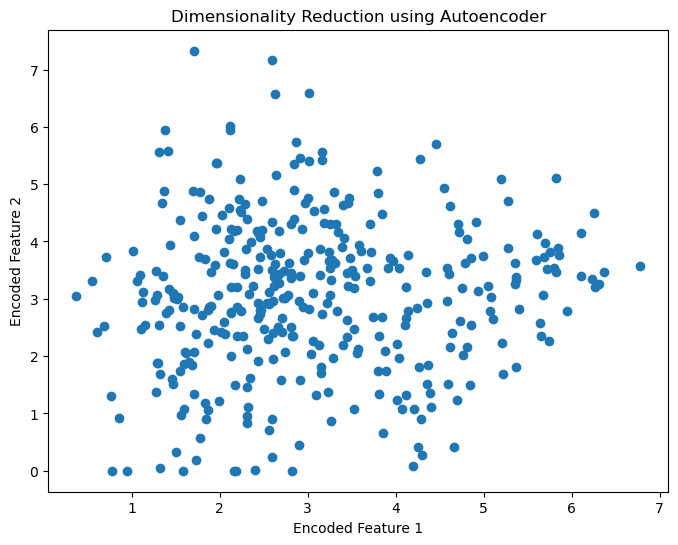

In [9]:
# Plot Reduced Dimensions

plt.figure(figsize=(8,6))

plt.scatter(
    encoded_data[:,0],
    encoded_data[:,1]
)

plt.xlabel("Encoded Feature 1")
plt.ylabel("Encoded Feature 2")

plt.title("Dimensionality Reduction using Autoencoder")

plt.show()